### Works fine with Google Colab

In [1]:
!git clone https://github.com/eyaler/face_toolbox_keras.git
%cd face_toolbox_keras

Cloning into 'face_toolbox_keras'...
remote: Enumerating objects: 308, done.
remote: Total 308 (delta 0), reused 0 (delta 0), pack-reused 308
Receiving objects: 100% (308/308), 248.43 MiB | 32.39 MiB/s, done.
Resolving deltas: 100% (144/144), done.
Checking out files: 100% (43/43), done.
/content/face_toolbox_keras


In [2]:
#!gdown https://drive.google.com/uc?id=1H37LER8mRRI4q_nxpS3uQz3DcGHkTrNU
#!mv lresnet100e_ir_keras.h5 ./models/verifier/insightface/lresnet100e_ir_keras.h5
#!gdown https://drive.google.com/uc?id=18MyyXQIwhR5I6gzipYMiJ9ywgvFWQMvI
#!mv backbone_ir50_ms1m_keras.h5 ./models/verifier/face_evoLVe_ir50/backbone_ir50_ms1m_keras.h5
#!gdown https://drive.google.com/uc?id=1P_eQHU8bNJEsB6hHt_fnltOwQVKIfhiX
#!mv backbone_ir50_asia_keras.h5 ./models/verifier/face_evoLVe_ir50/backbone_ir50_asia_keras.h5

Some core libraries and corresponding versions

In [ ]:
!pip install keras==2.2.4
%tensorflow_version 1.x
!pip install h5py==2.10.0

In [18]:
import warnings
warnings.filterwarnings("ignore")

In [19]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

---

Image resizing function

In [20]:
def resize_image(im, max_size=768):
    if np.max(im.shape) > max_size:
        ratio = max_size / np.max(im.shape)
        print(f"Resize image to ({str(int(im.shape[1]*ratio))}, {str(int(im.shape[0]*ratio))}).")
        return cv2.resize(im, (0,0), fx=ratio, fy=ratio)
    return im

Use the following cells if you are working with ground truth pixel data

In [21]:
#EXECUTE IF WORKING WITH THE CSV LANDMARKS, PIXELS DATA
#import numpy as np
#import pandas as pd
#import matplotlib.pyplot as plt
#import math
#from keras.models import *
#from sklearn.model_selection import train_test_split
#import keras
#import tensorflow as tf

In [22]:
#EXECUTE IF WORKING WITH THE CSV LANDMARKS, PIXELS DATA
#Read in data
#df = pd.read_csv('./test448.csv')
#df.fillna(method = 'ffill',inplace = True)
#def mse2(x, y):
#	return tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=y, labels= x)) 

#imgs = []
#for i in range(0,448):
#    img = df['Image'][i].split(' ')
#    img = ['0' if x == '' else x for x in img]
#    imgs.append(img)
#image_list = np.array(imgs,dtype = 'float')
#X_val = image_list.reshape(-1,96,96,1)
#print(X_val)


#training = df.drop('Image',axis = 1)
#y_train = []
#for i in range(0,448):
#    y = training.iloc[i,:]
#    y_train.append(y)
#y_val = np.array(y_train,dtype = 'float')

In [23]:
#EXECUTE IF WORKING WITH THE CSV LANDMARKS, PIXELS DATA
#index=1
#plt.figure(figsize=(7,7))
#plt.subplot(1,2,1)
#for i in range(0, len(y_val[index])-1, 2):
#    x = int(y_val[index][i])
#    y = int(y_val[index][i+1])
#    plt.scatter(x,y)
#plt.imshow(X_val[index].reshape(96,96), cmap='gray')
#plt.title("Image with Ground Truth Keypoints")
#plt.subplot(1,2,2)
#plt.imshow(X_val[index].reshape(96,96), cmap='gray')
#plt.title("Image")
#plt.show() 

---
# 0. Coordinate ordering

The coordinate in this demo has ordering `(x, y)`, which follows the format fo numpy array: `x` is the vertical axis and `y` the horizontal axis.

---
# 1. Face detection

Face deteciton using S3FD and FAN.

In [24]:
from models.detector import face_detector

In [ ]:
fd = face_detector.FaceAlignmentDetector(
    lmd_weights_path="./models/detector/FAN/2DFAN-4_keras.h5"# 2DFAN-4_keras.h5, 2DFAN-1_keras.h5
)

In [ ]:
#Use this cell if you are working with ground truth pixel data
#EXECUTE IF WORKING WITH THE CSV LANDMARKS, PIXELS DATA
#import cv2
#gray = cv2.cvtColor(X_val[index], cv2.COLOR_BGR2GRAY)
#color_img = cv2.merge([gray,gray,gray])
#print(X_val[index].shape)
#print(color_img.shape)
#newarr = X_val[index].reshape(96,96)
#print(newarr.shape)
#zer = np.zeros((96, 96))
#stacked_img = np.stack((newarr,zer,zer)*1, axis=-1)
#print(stacked_img.shape)

In [ ]:
def load(path):
    """takes as input the path to a .pts and returns a list of 
	tuples of floats containing the points in in the form:
	[(x_0, y_0, z_0),
	 (x_1, y_1, z_1),
	 ...
	 (x_n, y_n, z_n)]"""
    with open(path) as f:
        rows = [rows.strip() for rows in f]
    
    """Use the curly braces to find the start and end of the point data""" 
    head = rows.index('{') + 1
    tail = rows.index('}')

    """Select the point data split into coordinates"""
    raw_points = rows[head:tail]
    coords_set = [point.split() for point in raw_points]

    """Convert entries from lists of strings to tuples of floats"""
    points = [tuple([float(point) for point in coords]) for coords in coords_set]
    return points

## Detect faces

In [13]:
# Test images are obtained on https://www.pexels.com/
def read_image(path):
  im = cv2.imread(path)[..., ::-1]
  im = resize_image(im) # Resize image to prevent GPU OOM.
  h, w, _ = im.shape
  plt.imshow(im)
  return im
#600|444|3
#jb->768|437|3

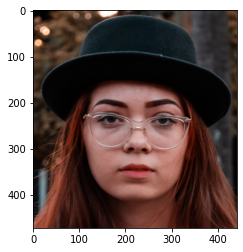

In [15]:
im = read_image("images/test.jpg")

In [ ]:
bboxes = fd.detect_face(im, with_landmarks=False)

### Detect face

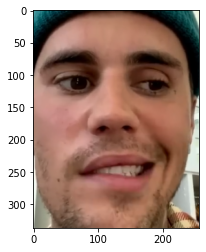

In [ ]:
assert len(bboxes) > 0, "No face detected."

# Display detected face
x0, y0, x1, y1, score = bboxes[0] # show the first detected face
x0, y0, x1, y1 = map(int, [x0, y0, x1, y1])

plt.imshow(im[x0:x1, y0:y1, :])

In [ ]:
#%cd images
#cv2.imwrite('image_face.png', im[x0:x1, y0:y1, :])
#im=im[x0:x1, y0:y1, :]

In [ ]:
#Use this cell if you are working with ground truth pixel data
#EXECUTE IF WORKING WITH THE CSV LANDMARKS, PIXELS DATA
#path1 = path[:-2] + 'ts'
#points = load(path1)
#print(points)
#print(len(points))

In [ ]:
#Use this cell if you are working with ground truth pixel data
#EXECUTE IF WORKING WITH THE CSV LANDMARKS, PIXELS DATA
#arr=[]
#for i in points:
#  arr.append([i[1], i[0]])
#arr = np.array(arr, dtype='float32')
#print(arr.shape)

## Detect faces and landmarks

`FaceDetector` will instantiate `FANLandmarksDetector` when calling `detect_face(with_landmarks=True)` the first time.

### Detect/predict landmarks on the face

In [ ]:
bboxes, landmarks = fd.detect_face(im, with_landmarks=True)

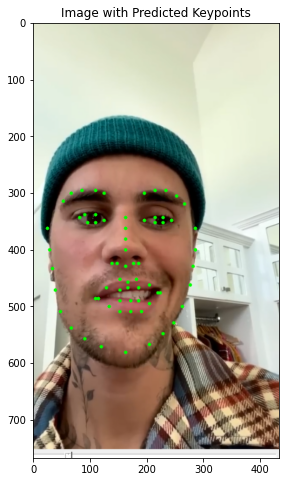

In [ ]:
# Display landmarks - predicted
plt.figure(figsize=(12,8))
num_faces = len(bboxes)
for i in range(num_faces):
    try:
        plt.subplot(1, 2, 1)
        plt.imshow(fd.draw_landmarks(im, landmarks[i], color=(0,255,0)))
        plt.title("Image with Predicted Keypoints")
    except:
        pass

# Display landmarks - ground truth
#im1 = cv2.imread(path)[..., ::-1]
#num_faces = len(bboxes)
#for i in range(num_faces):
#    try:
      #(1, num_faces, i+1) - if there are more faces than one in a single picture
#        plt.subplot(1, 2, 2)
#        plt.imshow(fd.draw_landmarks(im1, arr, color=(0,255,0)))
#        plt.title("Image with Ground Truth Keypoints")
#    except:
#        pass



# Half an image

##### Cut the image in half according to the nose (so this approach has many limits, the position of the face in the image should be "perfect)
##### If I use more points than one then I have problems with cropping the image and rejoining the parts

In [ ]:
l = landmarks.copy()

In [ ]:
delim = int(l[0][30][1])

In [ ]:
imleft = im.copy()
imleft[:, delim:, :] = [0.0,0.0,0.0]
imright = im.copy()
imright[:, :(delim-7), :] = [0.0,0.0,0.0]

In [ ]:
bboxes, landmarks = fd.detect_face(imleft, with_landmarks=True)

##### The landmarks for the shape of the face and nose are from the original (whole) picture, also the middle points of the mouth. See the landmarks: https://miro.medium.com/max/1400/1*tn5D7BMcvq57-T8qy7_tUQ.png. Then the image is divided into two images, the first one is with the left part of the picture shown and the right part is black (delimiter is the point 31, located on the nose). The same with the right part. With the function detect_face on the two images and with_landmarks=True, the landmarks for the halves can be discovered, and then we want to take some landmarks out of them because they are better predicted than when we use the whole picture. So, the landmarks for the left eyebrow, the left eye and the left half of the mouth are taken from the prediction on the left half of the face. The same is done for the right side. All these landmarks merged together and applied to the original image and we have better prediction as a whole.

In [ ]:
delimleft = delim
while len(bboxes)==0:
  delimleft+=1
  imleft = im.copy()
  imleft[:, delimleft:, :] = [0.0,0.0,0.0]
  bboxes, landmarks = fd.detect_face(imleft, with_landmarks=True)

In [ ]:
# left
for i in range(17,22):
  l[0][i] = landmarks[0][i]
for i in range(36,42):
  l[0][i] = landmarks[0][i]
for i in range(48,51):
  l[0][i] = landmarks[0][i]
for i in range(58,62):
  l[0][i] = landmarks[0][i]
l[0][67] = landmarks[0][67]

In [ ]:
bboxes, landmarks = fd.detect_face(imright, with_landmarks=True)

In [ ]:
delimright = delim
while len(bboxes)==0:
  delimright-=1
  imright = im.copy()
  imright[:, delimright:, :] = [0.0,0.0,0.0]
  bboxes, landmarks = fd.detect_face(imright, with_landmarks=True)

In [ ]:
# right
for i in range(22,27):
  l[0][i] = landmarks[0][i]
for i in range(42,48):
  l[0][i] = landmarks[0][i]
for i in range(52,57):
  l[0][i] = landmarks[0][i]
for i in range(63,66):
  l[0][i] = landmarks[0][i]

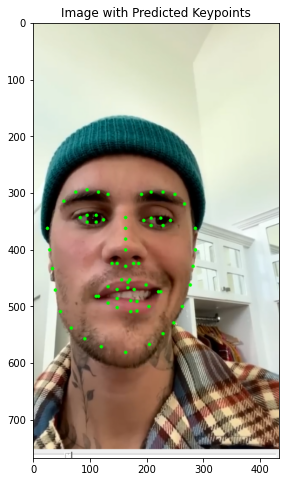

In [ ]:
plt.figure(figsize=(12,8))
num_faces = len(bboxes)
for i in range(num_faces):
    try:
        plt.subplot(1, 2, 1)
        plt.imshow(fd.draw_landmarks(im, l[i], color=(0,255,0)))
        plt.title("Image with Predicted Keypoints")
    except:
        pass


**Connecting points**
##### This section is about connecting points to more precisely cut the image into two halves (it's not used in this approach).

In [ ]:
for i in range(0,30):
  l[0][i] = [0., 0.]
for i in range(31,51):
  l[0][i] = [0., 0.]
for i in range(52,57):
  l[0][i] = [0., 0.]
for i in range(58,68):
  l[0][i] = [0., 0.]
print(l)

In [ ]:
y=[l[0][30][0], l[0][51][0], l[0][57][0]]
x=[l[0][30][1], l[0][51][1], l[0][57][1]]
print(x)
print(y)

[194.0, 190.0, 180.0]
[422.0, 480.0, 547.0]


In [ ]:
import matplotlib.pyplot as plt

def connectpoints(x,y,p1,p2):
    x1, x2 = x[p1], x[p2]
    y1, y2 = y[p1], y[p2]
    plt.plot([x1,x2],[y1,y2],'k-')

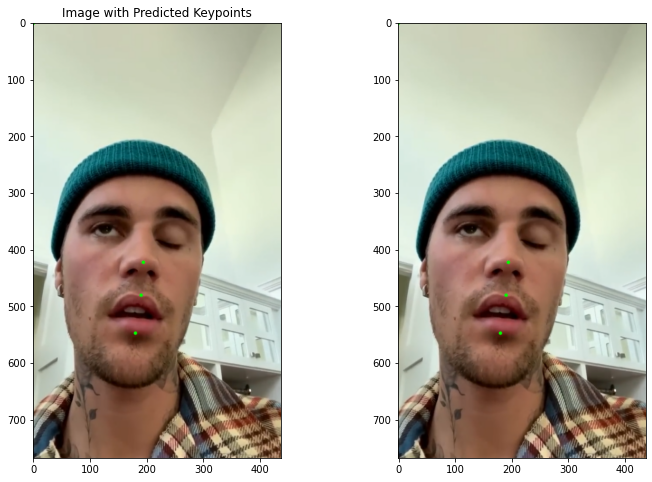

In [ ]:
plt.figure(figsize=(12,8))
num_faces = len(bboxes)
for i in range(num_faces):
    try:
        plt.subplot(1, 2, 1)
        
        plt.imshow(fd.draw_landmarks(im, l[i], color=(0,255,0)))
        plt.title("Image with Predicted Keypoints")
    except:
        pass

#im1 = cv2.imread(path)[..., ::-1]
im1=im
num_faces = len(bboxes)
for i in range(num_faces):
   try:
       plt.subplot(1, 2, 2)
       
       plt.imshow(fd.draw_landmarks(im1, l[i], color=(0,255,0)))
       connectpoints(x,y,0,1)
       connectpoints(x,y,1,2)
       plt.title("Image with Ground Truth Keypoints")
   except:
       pass

# **Justin** **Bieber** video
# Landmarks for each frame of the video and then reassemble them into a final video

###### In this approach each frame/image goes through the algorithm as a whole image, not as halves and merged afterwards. This section is for predicting whole video, not just pictures

In [ ]:
import cv2
import numpy as np
import pandas as pd
import os
import json
import tensorflow as tf

def load_video(path_to_video):
    video = cv2.VideoCapture(path_to_video)
    return video

def get_frameCount(video):
    frame_count = video.get(cv2.CAP_PROP_FRAME_COUNT)
    return frame_count

In [ ]:
path_to_video = "images" + os.sep +  "Justin Bieber.mp4"

In [ ]:
v = load_video(path_to_video)
number_of_frames = get_frameCount(v)

In [ ]:
# Display landmarks for each frame and save the new images so you can reassemble them into a final video at the end
frame_count = 0
img_count=0
while frame_count < number_of_frames:
  (taken, im) = v.read()
  if im is not None:
    im = resize_image(im) # Resize image to prevent GPU OOM.
    h, w, _ = im.shape
    bboxes = fd.detect_face(im, with_landmarks=False)
    assert len(bboxes) > 0, "No face detected."

    # Display detected face
    x0, y0, x1, y1, score = bboxes[0] # show the first detected face
    x0, y0, x1, y1 = map(int, [x0, y0, x1, y1])

    bboxes, landmarks = fd.detect_face(im, with_landmarks=True)

    cv2.imwrite("images" + os.sep + 'image'+str(img_count)+'.jpg', fd.draw_landmarks(im, landmarks[0], color=(0,255,0)))
    img_count=img_count+1
    if cv2.waitKey(1) & 0xFF == ord('q'):
      # release the cap object
      v.release()
      # close all windows
      cv2.destroyAllWindows()
      break
  frame_count=frame_count+1


Resize image to (432, 768).

Building FAN for landmarks detection...
Done.
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
Resize image to (432, 768).
R

In [ ]:
# Generate a video from previous saved images with landmarks included
import glob
import re

img_arr=[]
numbers = re.compile(r'(\d+)')
def numSort(value):
  parts = numbers.split(value)
  parts[1::2] = map(int, parts[1::2])
  return parts
for filename in sorted(glob.glob('/content/face_toolbox_keras/images/*jpg'), key=numSort):
  img = cv2.imread(filename)
  height, width, layers = img.shape
  size = (width, height)
  img_arr.append(img)

out = cv2.VideoWriter('videoJB.mp4', cv2.VideoWriter_fourcc(*'DIVX'), 15, size)
for i in range(len(img_arr)):
  out.write(img_arr[i])
out.release()

Merge two images

In [ ]:
from PIL import Image
#Read the two images
image1 = Image.open('images/aszz3.jpg')
image1.show()
image2 = Image.open('images/aszz4.jpg')
image2.show()
#resize, first image
image1 = image1.resize((299, 450))
image1_size = image1.size
image2_size = image2.size
new_image = Image.new('RGB',(2*image1_size[0], image1_size[1]), (250,250,250))
new_image.paste(image1,(0,0))
new_image.paste(image2,(image1_size[0],0))
new_image.save("images/merged_image.jpg","JPEG")
new_image.show()

Mirror image

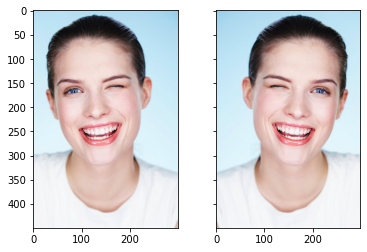

In [ ]:
import matplotlib.pyplot as plt
import imageio
im = imageio.imread('images/aszz4.jpg') 

fig, axs = plt.subplots(1, 2, sharey=True)

axs[0].imshow(im)
axs[1].imshow(im[:, ::-1, :])

---
# 2. Face parsing

Face parsing using BiSeNet.

In [ ]:
from models.parser import face_parser

In [ ]:
prs = face_parser.FaceParser()

## Parse without deteciton

In [ ]:
out = prs.parse_face(im)

In [ ]:
plt.imshow(out[0])

In [ ]:
# Show parsing result with annotations

from utils.visualize import show_parsing_with_annos
show_parsing_with_annos(out[0])

## Parse with detection

Parsing network has its best performance on single face (even better if aligned).

In [ ]:
im = cv2.imread("images/26041966_1.jpg")[..., ::-1]
im = resize_image(im) # Resize image to prevent GPU OOM.
h, w, _ = im.shape
plt.imshow(im)

In [ ]:
# Set detector into FaceParser
try:
    fd
except:
    from detector import face_detector
    fd = face_detector.FaceAlignmentDetector()
    
prs.set_detector(fd)
# prs.remove_detector()

In [ ]:
out = prs.parse_face(im, with_detection=True)

In [ ]:
#plt.figure(figsize=(15,8))
num_faces = len(out)
for i in range(num_faces):
    try:
        plt.subplot(1, num_faces, i+1)
        plt.imshow(out[i])
    except:
        pass

---
# 3. Detect irises

Iris detection using ELG (Eye region Landmarks based Gaze estimation).

In [ ]:
from models.detector.iris_detector import IrisDetector

## Detect iris, eyelibs and pulpils

In [ ]:
im = cv2.imread("images/face15.jpg")[..., ::-1]
im = resize_image(im) # Resize image to prevent GPU OOM.
h, w, _ = im.shape
plt.imshow(im)

In [ ]:
idet = IrisDetector()

In [ ]:
idet.set_detector(fd)

In [ ]:
eye_lms = idet.detect_iris(im)

In [ ]:
# Display detection result
plt.figure(figsize=(15,10))
draw = idet.draw_pupil(im, eye_lms[0][0,...]) # draw left eye
draw = idet.draw_pupil(draw, eye_lms[0][1,...]) # draw right eye
bboxes = fd.detect_face(im, with_landmarks=False)
x0, y0, x1, y1, _ = bboxes[0].astype(np.int32)
plt.subplot(1,2,1)
plt.imshow(draw)
plt.subplot(1,2,2)
plt.imshow(draw[x0:x1, y0:y1])

---
# 4. Face verification

Face verification using facenet.

In [ ]:
from models.verifier.face_verifier import FaceVerifier

In [ ]:
im1 = cv2.imread("images/test0.jpg")[..., ::-1]
im1 = resize_image(im1) # Resize image to prevent GPU OOM.
im2 = cv2.imread("images/BO1.jpg")[..., ::-1]
im2 = resize_image(im2) # Resize image to prevent GPU OOM.
im3 = cv2.imread("images/DT.jpg")[..., ::-1]
im3 = resize_image(im3) # Resize image to prevent GPU OOM.

In [ ]:
fv = FaceVerifier(classes=512, extractor="facenet") # extractor="insightface"

In [ ]:
fv.set_detector(fd)

## Verify if two given faces are the same person

In [ ]:
# Face verification
result1, distance1 = fv.verify(im1, im2, threshold=0.5, with_detection=True, with_alignment=False, return_distance=True)
result2, distance2 = fv.verify(im1, im3, threshold=0.5, with_detection=True, with_alignment=False, return_distance=True)

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(1,3,1)
plt.title(f"Source face")
plt.imshow(im1)
plt.subplot(1,3,2)
plt.title(f"Same person: {str(result1)}\n Cosine distance: {str(round(distance1, 2))}")
plt.imshow(im2)
plt.subplot(1,3,3)
plt.title(f"Same person: {str(result2)}\n Cosine distance: {str(round(distance2, 2))}")
plt.imshow(im3)

---
# 5. Gender and Age Estimation

Gender/Age estimation using insightface mobilenet.

In [ ]:
from models.estimator.gender_age_estimator import GenderAgeEstimator

In [ ]:
im = cv2.imread("images/BO1.jpg")[..., ::-1]
im = resize_image(im) # Resize image to prevent GPU OOM.
h, w, _ = im.shape
plt.imshow(im)

In [ ]:
gae = GenderAgeEstimator(model_type="insightface")

In [ ]:
gae.set_detector(fd)

In [ ]:
gender, age = gae.predict_gender_age(im, with_detection=True)

In [ ]:
print("Gender: female") if gender == 0 else print("Gender: male")
print(f"Age: {str(age)}")